# CNN для обратной задачи DBM

Цель — восстановить параметры

$$
\theta = \left(\eta, E_{\mathrm{bd}}^{(0)}, l_c, k\right)
$$

по бинарной маске электрического дерева размером `128 x 128`.

Качество CNN сравнивается с Random Forest на одинаковом разбиении без утечки данных.

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.nn.functional import conv2d
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")

PyTorch: 2.14.1+cu130
Device: cpu


In [2]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "ml_dataset"
DATA_FILE = DATA_DIR / "dataset_inverse.csv"
RESULTS_DIR = PROJECT_ROOT / "results" / "cnn_inverse"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_FILE.is_file(), DATA_FILE

print("Корень проекта:", PROJECT_ROOT)
print("Датасет:", DATA_FILE)
print("Результаты:", RESULTS_DIR)

Корень проекта: /home/artur/PycharmProjects/Mathprac
Датасет: /home/artur/PycharmProjects/Mathprac/data/ml_dataset/dataset_inverse.csv
Результаты: /home/artur/PycharmProjects/Mathprac/results/cnn_inverse


In [3]:
TARGET_COLUMNS = [
    "eta",
    "mean_breakdown_field",
    "correlation_length",
    "weibull_shape",
]

dataset = pd.read_csv(
    DATA_FILE,
    dtype={
        "disorder_seed": "uint64",
        "random_seed": "uint64",
    },
)

required_columns = {
    "run_id",
    "point_id",
    "disorder_seed",
    "split",
    "image_path",
    *TARGET_COLUMNS,
}

missing_columns = required_columns - set(dataset.columns)

assert not missing_columns, missing_columns
assert dataset["run_id"].notna().all()
assert dataset["run_id"].is_unique

print("Количество деревьев:", len(dataset))
print("Количество столбцов:", dataset.shape[1])

display(dataset[list(required_columns)].head())

Количество деревьев: 10199
Количество столбцов: 45


,eta,point_id,correlation_length,weibull_shape,image_path,run_id,split,mean_breakdown_field,disorder_seed
0,1.188938,global-000003,2,14.289726,images/global-000003-m0-g0.npz,global-000003-m0-g0,train,2.922237,11321135477748637079
1,0.787852,global-000007,14,2.879581,images/global-000007-m0-g0.npz,global-000007-m0-g0,train,2.743639,702538933303249406
2,0.509025,global-000008,4,6.943663,images/global-000008-m0-g0.npz,global-000008-m0-g0,train,3.220241,12261239717694141126
3,1.839728,global-000009,15,13.146752,images/global-000009-m0-g0.npz,global-000009-m0-g0,train,2.881764,15809094070047858094
4,2.930976,global-000010,4,2.767735,images/global-000010-m0-g0.npz,global-000010-m0-g0,train,3.090365,12772985709587214284


In [4]:
from sklearn.model_selection import GroupShuffleSplit

train_pool = dataset[
    dataset["split"] == "train"
].copy()

test_data = dataset[
    dataset["split"] == "test"
].copy()

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=SEED,
)

train_indices, validation_indices = next(
    group_split.split(
        train_pool,
        groups=train_pool["point_id"],
    )
)

train_data = train_pool.iloc[train_indices].copy()
validation_data = train_pool.iloc[validation_indices].copy()

print("Train:", len(train_data))
print("Validation:", len(validation_data))
print("Test:", len(test_data))

Train: 6560
Validation: 1706
Test: 1933


In [5]:
train_points = set(train_data["point_id"])
validation_points = set(validation_data["point_id"])

assert train_points.isdisjoint(validation_points)

train_seeds = set(train_data["disorder_seed"])
validation_seeds = set(validation_data["disorder_seed"])
test_seeds = set(test_data["disorder_seed"])

assert train_seeds.isdisjoint(validation_seeds)
assert train_seeds.isdisjoint(test_seeds)
assert validation_seeds.isdisjoint(test_seeds)

print("Общих point_id между train и validation нет")
print("Общих disorder_seed между выборками нет")

Общих point_id между train и validation нет
Общих disorder_seed между выборками нет


In [6]:
assert dataset["image_path"].notna().all()

image_files = dataset["image_path"].map(
    lambda path: DATA_DIR / path
)

missing_images = [
    path for path in image_files
    if not path.is_file()
]

assert not missing_images, missing_images[:5]

example_row = train_data.iloc[0]
example_file = DATA_DIR / example_row["image_path"]

with np.load(example_file, allow_pickle=False) as saved:
    example_mask = saved["channel"].astype(np.float32)

assert example_mask.shape == (128, 128)
assert np.isin(example_mask, [0.0, 1.0]).all()

print("Файл:", example_file)
print("Размер маски:", example_mask.shape)
print("Ячеек канала:", int(example_mask.sum()))

Файл: /home/artur/PycharmProjects/Mathprac/data/ml_dataset/images/global-000003-m0-g0.npz
Размер маски: (128, 128)
Ячеек канала: 349


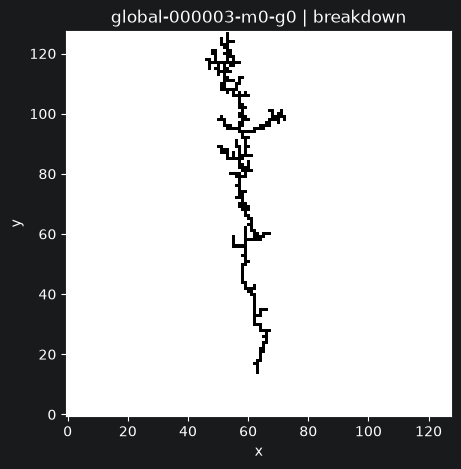

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.imshow(
    example_mask,
    cmap="gray_r",
    origin="lower",
)

ax.set(
    title=f'{example_row["run_id"]} | {example_row["status"]}',
    xlabel="x",
    ylabel="y",
)

plt.show()

In [8]:
class DBMMaskDataset(Dataset):
    def __init__(
        self,
        frame,
        data_dir,
        target_mean,
        target_std,
        horizontal_flip=False,
    ):
        self.frame = frame.reset_index(drop=True)
        self.data_dir = Path(data_dir)

        self.target_mean = target_mean.to_numpy(
            dtype=np.float32
        )
        self.target_std = target_std.to_numpy(
            dtype=np.float32
        )

        self.horizontal_flip = horizontal_flip

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image_file = self.data_dir / row["image_path"]

        with np.load(image_file, allow_pickle=False) as saved:
            mask = saved["channel"].astype(np.float32)

        if self.horizontal_flip and random.random() < 0.5:
            mask = np.fliplr(mask).copy()

        mask = torch.from_numpy(mask).unsqueeze(0)

        target = row[TARGET_COLUMNS].to_numpy(
            dtype=np.float32
        )
        target = (
            target - self.target_mean
        ) / self.target_std
        target = torch.from_numpy(target)

        return mask, target

In [9]:
target_mean = train_data[TARGET_COLUMNS].mean()
target_std = train_data[TARGET_COLUMNS].std(ddof=0)

assert (target_std > 0).all()

target_statistics = pd.DataFrame(
    {
        "mean": target_mean,
        "std": target_std,
    }
)

display(target_statistics.round(4))

,mean,std
eta,1.7433,0.7346
mean_breakdown_field,2.9577,0.1678
correlation_length,6.1079,4.4250
weibull_shape,7.5033,3.8223


In [10]:
USE_HORIZONTAL_FLIP = True

train_dataset = DBMMaskDataset(
    frame=train_data,
    data_dir=DATA_DIR,
    target_mean=target_mean,
    target_std=target_std,
    horizontal_flip=USE_HORIZONTAL_FLIP,
)

validation_dataset = DBMMaskDataset(
    frame=validation_data,
    data_dir=DATA_DIR,
    target_mean=target_mean,
    target_std=target_std,
    horizontal_flip=False,
)

test_dataset = DBMMaskDataset(
    frame=test_data,
    data_dir=DATA_DIR,
    target_mean=target_mean,
    target_std=target_std,
    horizontal_flip=False,
)

sample_mask, sample_target = train_dataset[0]

print("Train:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

print("Размер маски:", sample_mask.shape)
print("Размер цели:", sample_target.shape)
print("Тип маски:", sample_mask.dtype)
print("Нормализованная цель:", sample_target)

Train: 6560
Validation: 1706
Test: 1933
Размер маски: torch.Size([1, 128, 128])
Размер цели: torch.Size([4])
Тип маски: torch.float32
Нормализованная цель: tensor([-0.7546, -0.2115, -0.9283,  1.7755])


In [11]:
BATCH_SIZE = 64
NUM_WORKERS = 4
PIN_MEMORY = DEVICE.type == "cuda"

data_generator = torch.Generator()
data_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    generator=data_generator,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

batch_masks, batch_targets = next(iter(train_loader))

print("Батч масок:", batch_masks.shape)
print("Батч целей:", batch_targets.shape)

Батч масок: torch.Size([64, 1, 128, 128])
Батч целей: torch.Size([64, 4])


In [12]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        if in_channels == out_channels:
            self.shortcut = nn.Identity()
        else:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )
    def forward(self, x):
        identity = self.shortcut(x)

        output = self.relu(
            self.bn1(self.conv1(x))
        )
        output = self.bn2(
            self.conv2(output)
        )

        output = self.relu(output + identity)

        return output

## Многозадачная residual CNN

Общий энкодер извлекает признаки дерева, после чего четыре отдельные головы восстанавливают параметры DBM.

In [13]:
class DBMResidualCNN(nn.Module):
    def __init__(self, number_of_targets=4):
        super().__init__()

        self.encoder = nn.Sequential(
            ResidualBlock(1, 16),
            nn.MaxPool2d(kernel_size=2),

            ResidualBlock(16, 32),
            nn.MaxPool2d(kernel_size=2),

            ResidualBlock(32, 64),
            nn.MaxPool2d(kernel_size=2),

            ResidualBlock(64, 128),
            nn.MaxPool2d(kernel_size=2),
        )
        self.average_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.maximum_pool = nn.AdaptiveMaxPool2d((4, 4))

        self.shared_layers = nn.Sequential(
            nn.Linear(4096, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
                nn.ReLU(inplace=True),
        )

        self.heads = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(128, 32),
                    nn.ReLU(inplace=True),
                    nn.Dropout(0.10),
                    nn.Linear(32, 1),
                )
                for _ in range(number_of_targets)
            ]
        )

    def forward(self, x):
        features = self.encoder(x)

        average_features = self.average_pool(
            features
        ).flatten(1)

        maximum_features = self.maximum_pool(
            features
        ).flatten(1)

        pooled_features = torch.cat(
            [average_features, maximum_features],
            dim=1,
        )

        embedding = self.shared_layers(
            pooled_features
        )

        predictions = torch.cat(
            [head(embedding) for head in self.heads],
            dim=1,
        )

        return predictions

## Одна эпоха обучения

Функция выполняет прямой проход, вычисляет ошибку и при обучении обновляет веса CNN.

In [14]:
def run_epoch(
        model,
        loader,
        criterion,
        optimizer=None,
):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    for masks, targets in loader:
        masks = masks.to(
            DEVICE,
            non_blocking=PIN_MEMORY,
        )
        targets = targets.to(
            DEVICE,
            non_blocking=PIN_MEMORY,
        )
        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            predictions = model(masks)
            loss = criterion(predictions, targets)

            if is_training:
                loss.backward()
                optimizer.step()

        total_loss += (
            loss.item() * masks.size(0)
        )

    average_loss = total_loss / len(loader.dataset)

    return average_loss

## Обучение CNN

Обучаем модель до 70 эпох, сохраняем состояние с минимальной validation loss и останавливаем обучение при отсутствии улучшения.

In [15]:
model = DBMResidualCNN(
    number_of_targets=len(TARGET_COLUMNS)
).to(DEVICE)

criterion = nn.SmoothL1Loss(beta=1.0)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

In [16]:
MAX_EPOCHS = 70
EARLY_STOPPING_PATIENCE = 10
MIN_IMPROVEMENT = 1e-4
BEST_MODEL_FILE = RESULTS_DIR / "best_cnn.pt"
history = []
best_validation_loss = np.inf
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(
    model=model,
    loader=train_loader,
    criterion=criterion,
    optimizer=optimizer
    )
    validation_loss = run_epoch(
    model=model,
    loader=validation_loader,
    criterion=criterion
    )
    scheduler.step(validation_loss)
    learning_rate = optimizer.param_groups[0]["lr"]

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_loss": validation_loss,
            "learning_rate": learning_rate,
        }
    )

    improved = (
        validation_loss
        < best_validation_loss - MIN_IMPROVEMENT
    )

    if improved:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "validation_loss": validation_loss,
                "target_mean": target_mean.to_dict(),
                "target_std": target_std.to_dict(),
                "target_columns": TARGET_COLUMNS,
            },
            BEST_MODEL_FILE,
        )
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:02d} | "
        f"train: {train_loss:.5f} | "
        f"validation: {validation_loss:.5f} | "
        f"lr: {learning_rate:.2e}"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping")
        break

Epoch 01 | train: 0.36029 | validation: 0.33529 | lr: 1.00e-03
Epoch 02 | train: 0.32577 | validation: 0.36583 | lr: 1.00e-03
Epoch 03 | train: 0.31089 | validation: 0.30545 | lr: 1.00e-03
Epoch 04 | train: 0.30335 | validation: 0.31213 | lr: 1.00e-03
Epoch 05 | train: 0.29298 | validation: 0.30885 | lr: 1.00e-03
Epoch 06 | train: 0.28490 | validation: 0.30855 | lr: 1.00e-03
Epoch 07 | train: 0.28079 | validation: 0.37707 | lr: 5.00e-04
Epoch 08 | train: 0.26955 | validation: 0.27198 | lr: 5.00e-04
Epoch 09 | train: 0.26460 | validation: 0.28549 | lr: 5.00e-04
Epoch 10 | train: 0.26399 | validation: 0.28069 | lr: 5.00e-04
Epoch 11 | train: 0.25979 | validation: 0.26752 | lr: 5.00e-04
Epoch 12 | train: 0.25545 | validation: 0.30161 | lr: 5.00e-04
Epoch 13 | train: 0.25478 | validation: 0.27033 | lr: 5.00e-04
Epoch 14 | train: 0.25047 | validation: 0.34753 | lr: 5.00e-04
Epoch 15 | train: 0.25048 | validation: 0.28519 | lr: 2.50e-04
Epoch 16 | train: 0.24187 | validation: 0.28371 | lr: 2

## Результаты обучения

Загружаем состояние с минимальной validation loss и анализируем динамику обучения.

Лучшая эпоха: 21
Лучшая validation loss: 0.26565


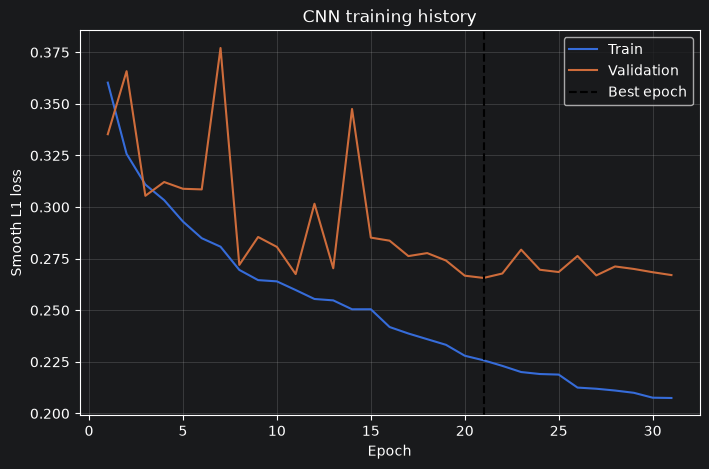

In [17]:
history_frame = pd.DataFrame(history)

history_frame.to_csv(
    RESULTS_DIR / "training_history.csv",
    index=False,
)

best_row = history_frame.loc[
    history_frame["validation_loss"].idxmin()
]

checkpoint = torch.load(
    BEST_MODEL_FILE,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)
model.eval()

print("Лучшая эпоха:", checkpoint["epoch"])
print(
    "Лучшая validation loss:",
    f'{checkpoint["validation_loss"]:.5f}',
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    history_frame["epoch"],
    history_frame["train_loss"],
    label="Train",
)

ax.plot(
    history_frame["epoch"],
    history_frame["validation_loss"],
    label="Validation",
)

ax.axvline(
    best_row["epoch"],
    color="black",
    linestyle="--",
    label="Best epoch",
)

ax.set(
    xlabel="Epoch",
    ylabel="Smooth L1 loss",
    title="CNN training history",
)

ax.grid(alpha=0.3)
ax.legend()

plt.show()

## Метрики на validation

Переводим предсказания обратно в физические единицы и сравниваем CNN с медианным baseline.

In [18]:
def collect_predictions(model, loader):
    normalized_predictions = []
    normalized_targets = []

    model.eval()

    with torch.no_grad():
        for masks, targets in loader:
            masks = masks.to(
                DEVICE,
                non_blocking=PIN_MEMORY,
            )

            predictions = model(masks)

            normalized_predictions.append(
                predictions.cpu().numpy()
            )
            normalized_targets.append(
                targets.numpy()
            )

    return (
        np.concatenate(normalized_predictions),
        np.concatenate(normalized_targets),
    )

In [19]:
validation_prediction_normalized, validation_true_normalized = (
    collect_predictions(
        model,
        validation_loader,
    )
)

target_mean_array = target_mean[
    TARGET_COLUMNS
].to_numpy(dtype=np.float32)

target_std_array = target_std[
    TARGET_COLUMNS
].to_numpy(dtype=np.float32)

validation_prediction = (
    validation_prediction_normalized * target_std_array
    + target_mean_array
)

validation_true = (
    validation_true_normalized * target_std_array
    + target_mean_array
)

In [20]:
validation_metrics = []

for target_index, target in enumerate(TARGET_COLUMNS):
    true_values = validation_true[:, target_index]
    predicted_values = validation_prediction[:, target_index]

    mae = mean_absolute_error(
        true_values,
        predicted_values,
    )

    rmse = np.sqrt(
        mean_squared_error(
            true_values,
            predicted_values,
        )
    )

    r2 = r2_score(
        true_values,
        predicted_values,
    )

    target_range = (
        train_data[target].max()
        - train_data[target].min()
    )

    baseline_value = train_data[target].median()

    baseline_mae = mean_absolute_error(
        true_values,
        np.full_like(true_values, baseline_value),
    )

    validation_metrics.append(
        {
            "target": target,
            "mae": mae,
            "normalized_mae": mae / target_range,
            "rmse": rmse,
            "r2": r2,
            "baseline_mae": baseline_mae,
            "improvement_percent": (
                100 * (baseline_mae - mae) / baseline_mae
            ),
        }
    )

validation_metrics = pd.DataFrame(validation_metrics)

validation_metrics.to_csv(
    RESULTS_DIR / "validation_metrics.csv",
    index=False,
)

display(validation_metrics.round(4))

,target,mae,normalized_mae,rmse,r2,baseline_mae,improvement_percent
0,eta,0.2707,0.1083,0.3671,0.7622,0.6644,59.2595
1,mean_breakdown_field,0.1334,0.2224,0.1623,0.0690,0.1433,6.9080
2,correlation_length,2.7867,0.1990,3.5725,0.3519,3.7409,25.5087
3,weibull_shape,2.1191,0.1632,2.6965,0.5128,3.3022,35.8264


## Истинные и восстановленные параметры

Сравниваем предсказания CNN с истинными значениями параметров на validation.

In [21]:
TARGET_LABELS = {
    "eta": r"$\eta$",
    "mean_breakdown_field": r"$E_{\mathrm{bd}}^{(0)}$",
    "correlation_length": r"$l_c$",
    "weibull_shape": r"$k$",
}

validation_predictions_table = validation_data[
    [
        "run_id",
        "point_id",
        "disorder_seed",
        "status",
    ]
].reset_index(drop=True).copy()

for target_index, target in enumerate(TARGET_COLUMNS):
    validation_predictions_table[
        f"true_{target}"
    ] = validation_true[:, target_index]

    validation_predictions_table[
        f"predicted_{target}"
    ] = validation_prediction[:, target_index]

validation_predictions_table.to_csv(
    RESULTS_DIR / "validation_predictions.csv",
    index=False,
)

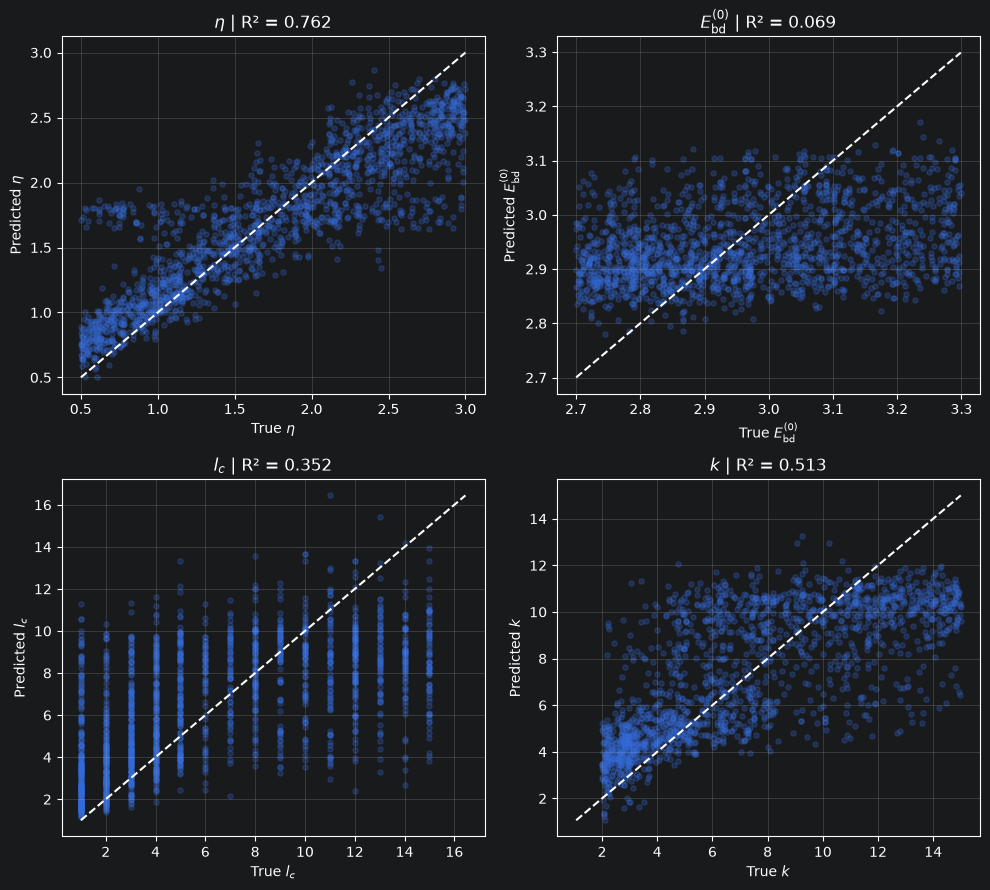

In [22]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 9),
)

for target_index, (target, ax) in enumerate(
    zip(TARGET_COLUMNS, axes.flat)
):
    true_values = validation_true[:, target_index]
    predicted_values = validation_prediction[:, target_index]

    minimum = min(
        true_values.min(),
        predicted_values.min(),
    )
    maximum = max(
        true_values.max(),
        predicted_values.max(),
    )

    target_r2 = validation_metrics.loc[
        validation_metrics["target"] == target,
        "r2",
    ].iloc[0]

    ax.scatter(
        true_values,
        predicted_values,
        s=14,
        alpha=0.25,
    )

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        color="white",
        linestyle="--",
    )

    ax.set(
        xlabel=f"True {TARGET_LABELS[target]}",
        ylabel=f"Predicted {TARGET_LABELS[target]}",
        title=(
            f"{TARGET_LABELS[target]}"
            f" | R² = {target_r2:.3f}"
        ),
    )

    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "validation_true_vs_pred.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### Интерпретация результатов CNN

Качество восстановления существенно различается между параметрами:

- **$\eta$ ($R^2=0.762$)** восстанавливается лучше всего: геометрия дерева содержит выраженную информацию о направленности роста.
- **$E_{\mathrm{bd}}^{(0)}$ ($R^2=0.069$)** практически не определяется по конечной маске. Модель в основном предсказывает значение, близкое к среднему.
- **$l_c$ ($R^2=0.352$)** восстанавливается частично: общий тренд присутствует, но разброс предсказаний остаётся большим.
- **$k$ ($R^2=0.513$)** восстанавливается умеренно хорошо, однако крайние значения стягиваются к центру диапазона.

Стягивание предсказаний к среднему указывает на неоднозначность обратной задачи: разные комбинации параметров могут приводить к похожей морфологии дерева. Таким образом, конечная маска наиболее информативна относительно $\eta$ и $k$, частично информативна относительно $l_c$ и почти не содержит информации о $E_{\mathrm{bd}}^{(0)}$.

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from src.morphology_features import MORPHOLOGY_FEATURES

FEATURE_COLUMNS = list(MORPHOLOGY_FEATURES)

X_train_rf = train_data[FEATURE_COLUMNS]
X_validation_rf = validation_data[FEATURE_COLUMNS]

y_train_rf = train_data[TARGET_COLUMNS]
y_validation_rf = validation_data[TARGET_COLUMNS]

rf_models = {}
rf_validation_predictions = {}
rf_metrics_rows = []

for target in TARGET_COLUMNS:
    rf_model = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=400,
                    max_features=0.7,
                    min_samples_leaf=2,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    rf_model.fit(
        X_train_rf,
        y_train_rf[target],
    )

    predictions = rf_model.predict(
        X_validation_rf
    )

    rf_models[target] = rf_model
    rf_validation_predictions[target] = predictions

    # Расчёт метрик
    true_values = y_validation_rf[target].to_numpy()

    mae = mean_absolute_error(
        true_values,
        predictions,
    )

    rmse = np.sqrt(
        mean_squared_error(
            true_values,
            predictions,
        )
    )

    r2 = r2_score(
        true_values,
        predictions,
    )

    target_range = (
        y_train_rf[target].max()
        - y_train_rf[target].min()
    )

    rf_metrics_rows.append(
        {
            "target": target,
            "mae": mae,
            "normalized_mae": mae / target_range,
            "rmse": rmse,
            "r2": r2,
        }
    )

    print(f"Обучена модель для {target}")


rf_validation_metrics = pd.DataFrame(
    rf_metrics_rows
)

display(
    rf_validation_metrics.round(4)
)

Обучена модель для eta
Обучена модель для mean_breakdown_field
Обучена модель для correlation_length
Обучена модель для weibull_shape


,target,mae,normalized_mae,rmse,r2
0,eta,0.2567,0.1028,0.3686,0.7603
1,mean_breakdown_field,0.1378,0.2297,0.1645,0.0446
2,correlation_length,3.2127,0.2295,3.9213,0.2191
3,weibull_shape,2.4489,0.1885,3.0119,0.3922


In [28]:
cnn_metrics_for_comparison = validation_metrics[
    [
        "target",
        "mae",
        "normalized_mae",
        "rmse",
        "r2",
    ]
].copy()

comparison_metrics = cnn_metrics_for_comparison.merge(
    rf_validation_metrics,
    on="target",
    suffixes=("_cnn", "_rf"),
)

comparison_metrics["best_mae"] = np.where(
    comparison_metrics["mae_cnn"]
    < comparison_metrics["mae_rf"],
    "CNN",
    "Random Forest",
)

comparison_metrics["best_r2"] = np.where(
    comparison_metrics["r2_cnn"]
    > comparison_metrics["r2_rf"],
    "CNN",
    "Random Forest",
)

comparison_table = comparison_metrics[
    [
        "target",
        "mae_cnn",
        "mae_rf",
        "r2_cnn",
        "r2_rf",
        "best_mae",
        "best_r2",
    ]
]

comparison_metrics.to_csv(
    RESULTS_DIR / "cnn_vs_random_forest_validation.csv",
    index=False,
)

display(
    comparison_table.round(4)
)

,target,mae_cnn,mae_rf,r2_cnn,r2_rf,best_mae,best_r2
0,eta,0.2707,0.2567,0.7622,0.7603,Random Forest,CNN
1,mean_breakdown_field,0.1334,0.1378,0.0690,0.0446,CNN,CNN
2,correlation_length,2.7867,3.2127,0.3519,0.2191,CNN,CNN
3,weibull_shape,2.1191,2.4489,0.5128,0.3922,CNN,CNN


### CNN и Random Forest

CNN превосходит Random Forest по коэффициенту $R^2$ для всех четырёх параметров и по MAE для трёх параметров из четырёх. Для $\eta$ результаты моделей практически совпадают, поэтому его основная информация уже содержится в рассчитанных морфологических признаках.

Наибольшее преимущество CNN наблюдается для $l_c$ и $k$. Следовательно, для их восстановления важна пространственная структура дерева, которая частично теряется при сведении маски к набору интегральных характеристик.

Обе модели показывают низкое качество для $E_{\mathrm{bd}}^{(0)}$. Это указывает на слабую идентифицируемость порога пробоя по конечной форме уже сформированного дерева.

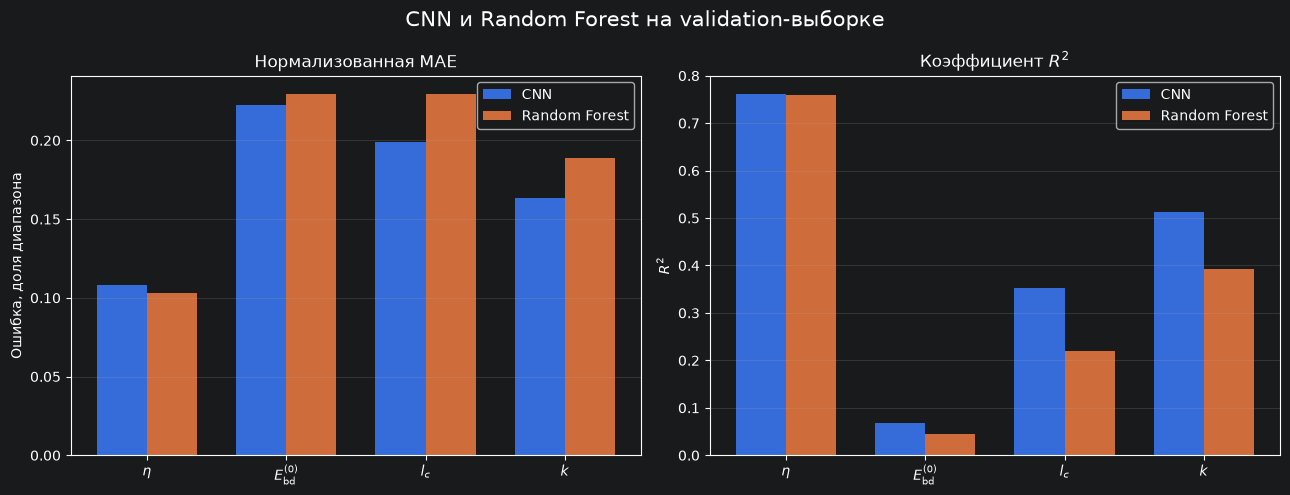

In [29]:
x = np.arange(len(TARGET_COLUMNS))
width = 0.36

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

axes[0].bar(
    x - width / 2,
    comparison_metrics["normalized_mae_cnn"],
    width,
    label="CNN",
)

axes[0].bar(
    x + width / 2,
    comparison_metrics["normalized_mae_rf"],
    width,
    label="Random Forest",
)

axes[0].set_title("Нормализованная MAE")
axes[0].set_ylabel("Ошибка, доля диапазона")
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [TARGET_LABELS[target] for target in TARGET_COLUMNS]
)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(
    x - width / 2,
    comparison_metrics["r2_cnn"],
    width,
    label="CNN",
)

axes[1].bar(
    x + width / 2,
    comparison_metrics["r2_rf"],
    width,
    label="Random Forest",
)

axes[1].set_title(r"Коэффициент $R^2$")
axes[1].set_ylabel(r"$R^2$")
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [TARGET_LABELS[target] for target in TARGET_COLUMNS]
)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle(
    "CNN и Random Forest на validation-выборке",
    fontsize=15,
)

fig.tight_layout()

fig.savefig(
    RESULTS_DIR / "cnn_vs_random_forest_validation.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

## Финальная оценка на test-выборке

После выбора архитектуры и анализа validation-выборки лучшая сохранённая CNN один раз оценивается на отложенной test-выборке. Test не использовался для обучения, ранней остановки или выбора гиперпараметров.

In [30]:
checkpoint = torch.load(
    BEST_MODEL_FILE,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(
    "Загружена модель с эпохи:",
    checkpoint["epoch"],
)
print(
    "Лучший validation loss:",
    round(checkpoint["validation_loss"], 5),
)

Загружена модель с эпохи: 21
Лучший validation loss: 0.26565


In [31]:
test_predictions_normalized, test_targets_normalized = (
    collect_predictions(
        model=model,
        loader=test_loader,
    )
)

target_mean_array = target_mean.to_numpy(
    dtype=np.float32
)

target_std_array = target_std.to_numpy(
    dtype=np.float32
)

test_predictions = (
    test_predictions_normalized * target_std_array
    + target_mean_array
)

test_targets = (
    test_targets_normalized * target_std_array
    + target_mean_array
)

print("Размер предсказаний:", test_predictions.shape)
print("Размер истинных значений:", test_targets.shape)

Размер предсказаний: (1933, 4)
Размер истинных значений: (1933, 4)


In [32]:
test_metrics_rows = []

for target_index, target in enumerate(TARGET_COLUMNS):
    true_values = test_targets[:, target_index]
    predicted_values = test_predictions[:, target_index]

    mae = mean_absolute_error(
        true_values,
        predicted_values,
    )

    rmse = np.sqrt(
        mean_squared_error(
            true_values,
            predicted_values,
        )
    )

    r2 = r2_score(
        true_values,
        predicted_values,
    )

    target_range = (
        train_data[target].max()
        - train_data[target].min()
    )

    normalized_mae = mae / target_range

    # Простая baseline: всегда предсказываем медиану train
    baseline_value = train_data[target].median()

    baseline_predictions = np.full(
        shape=len(true_values),
        fill_value=baseline_value,
    )

    baseline_mae = mean_absolute_error(
        true_values,
        baseline_predictions,
    )

    improvement_percent = (
        100
        * (baseline_mae - mae)
        / baseline_mae
    )

    test_metrics_rows.append(
        {
            "target": target,
            "mae": mae,
            "normalized_mae": normalized_mae,
            "rmse": rmse,
            "r2": r2,
            "baseline_mae": baseline_mae,
            "improvement_percent": improvement_percent,
        }
    )

test_metrics = pd.DataFrame(
    test_metrics_rows
)

test_metrics.to_csv(
    RESULTS_DIR / "test_metrics.csv",
    index=False,
)

display(
    test_metrics.round(4)
)

,target,mae,normalized_mae,rmse,r2,baseline_mae,improvement_percent
0,eta,0.2369,0.0948,0.3144,0.8100,0.6247,62.0819
1,mean_breakdown_field,0.1326,0.2210,0.1597,0.0741,0.1406,5.7297
2,correlation_length,3.1719,0.2266,4.0073,0.1912,4.2178,24.7962
3,weibull_shape,2.2629,0.1742,2.8378,0.4362,3.3299,32.0428


### Результаты на test-выборке

На полностью отложенной test-выборке лучше всего восстанавливается параметр $\eta$: модель объясняет 81% его вариации и уменьшает MAE относительно постоянного предсказания на 62%.

Параметр $k$ восстанавливается с умеренной точностью, а для $l_c$ сохраняется полезный, но менее устойчивый сигнал. Качество восстановления $E_{\mathrm{bd}}^{(0)}$ остаётся низким, что подтверждает его слабую идентифицируемость по конечной форме дерева.

В целом CNN переносит закономерности на новые точки параметрического пространства, хотя качество для $l_c$ и $k$ ниже, чем на validation-выборке.

In [33]:
metadata_columns = [
    column
    for column in [
        "run_id",
        "point_id",
        "disorder_seed",
        "status",
    ]
    if column in test_data.columns
]

test_predictions_table = (
    test_data[metadata_columns]
    .reset_index(drop=True)
    .copy()
)

for target_index, target in enumerate(TARGET_COLUMNS):
    test_predictions_table[f"true_{target}"] = (
        test_targets[:, target_index]
    )

    test_predictions_table[f"predicted_{target}"] = (
        test_predictions[:, target_index]
    )

test_predictions_table.to_csv(
    RESULTS_DIR / "test_predictions.csv",
    index=False,
)

display(
    test_predictions_table.head()
)

,run_id,point_id,disorder_seed,status,true_eta,predicted_eta,true_mean_breakdown_field,predicted_mean_breakdown_field,true_correlation_length,predicted_correlation_length,true_weibull_shape,predicted_weibull_shape
0,test-000000-m0-g0,test-000000,9721607773156599656,breakdown,0.799570,1.002376,2.816857,2.849316,11.000000,5.030210,12.415463,11.171050
1,test-000002-m0-g0,test-000002,8814814518989834480,breakdown,2.294968,1.957155,2.953032,2.883609,14.999998,6.968437,9.404525,10.843651
2,test-000002-m1-g0,test-000002,6501705061660704092,breakdown,2.294968,2.018146,2.953032,2.933443,14.999998,4.454609,9.404525,10.599432
3,test-000003-m0-g0,test-000003,5713537892996884079,breakdown,1.646924,1.524132,3.030428,2.941241,3.000000,3.704275,3.293578,3.759535
4,test-000003-m1-g0,test-000003,17243118706525910291,breakdown,1.646924,1.858049,3.030428,3.015324,3.000000,4.945835,3.293578,4.024131


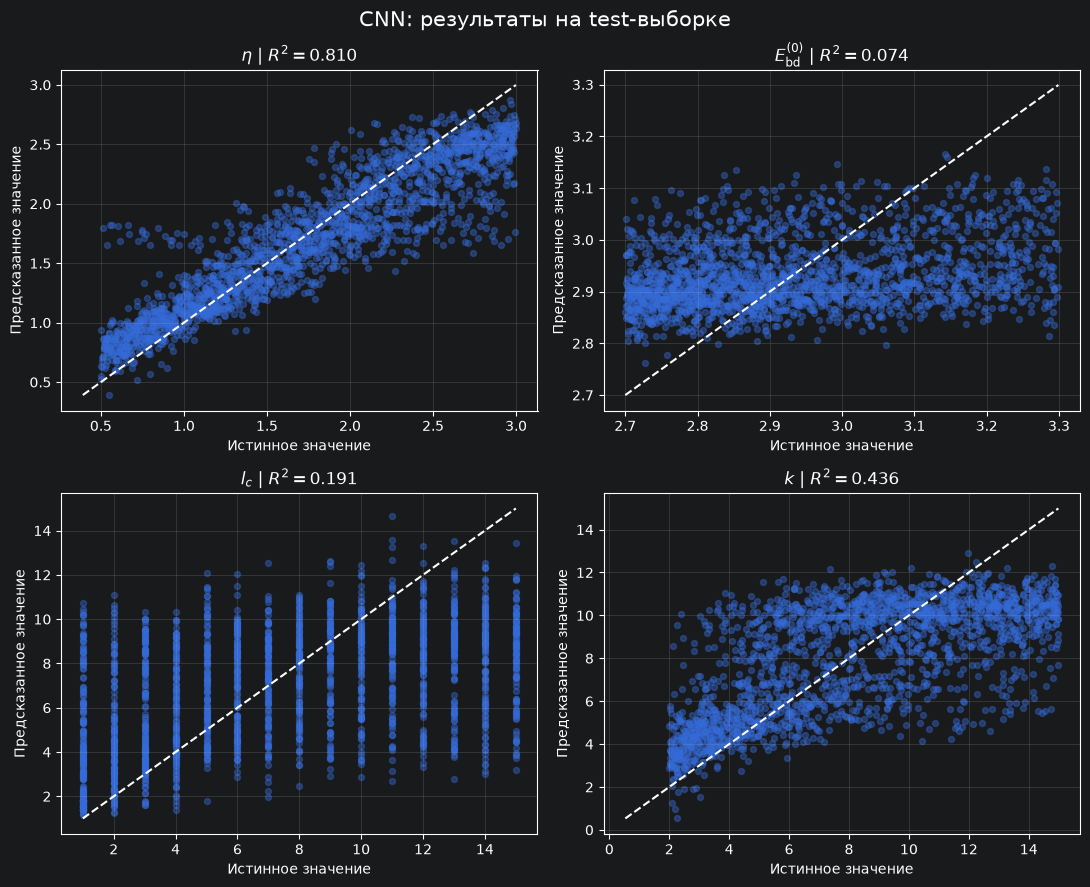

In [35]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 9),
)

for ax, target_index, target in zip(
    axes.ravel(),
    range(len(TARGET_COLUMNS)),
    TARGET_COLUMNS,
):
    true_values = test_targets[:, target_index]
    predicted_values = test_predictions[:, target_index]

    lower_bound = min(
        true_values.min(),
        predicted_values.min(),
    )
    upper_bound = max(
        true_values.max(),
        predicted_values.max(),
    )

    r2 = test_metrics.loc[
        test_metrics["target"] == target,
        "r2",
    ].iloc[0]

    ax.scatter(
        true_values,
        predicted_values,
        s=18,
        alpha=0.4,
    )

    ax.plot(
        [lower_bound, upper_bound],
        [lower_bound, upper_bound],
        linestyle="--",
        color="white",
        linewidth=1.5,
    )

    ax.set_title(
        f"{TARGET_LABELS[target]} | $R^2={r2:.3f}$"
    )
    ax.set_xlabel("Истинное значение")
    ax.set_ylabel("Предсказанное значение")
    ax.grid(alpha=0.25)

fig.suptitle(
    "CNN: результаты на test-выборке",
    fontsize=15,
)

fig.tight_layout()

fig.savefig(
    RESULTS_DIR / "test_true_vs_pred.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

In [36]:
RF_TEST_METRICS_FILE = (
    PROJECT_ROOT
    / "results"
    / "inverse_ml"
    / "test_metrics.csv"
)

assert RF_TEST_METRICS_FILE.is_file(), (
    RF_TEST_METRICS_FILE
)

rf_test_metrics_all = pd.read_csv(
    RF_TEST_METRICS_FILE
)

rf_final_test_metrics = (
    rf_test_metrics_all[
        rf_test_metrics_all["model"]
        == "Final Random Forest"
    ]
    [
        [
            "target",
            "mae",
            "normalized_mae",
            "rmse",
            "r2",
        ]
    ]
    .copy()
)

cnn_vs_rf_test = test_metrics[
    [
        "target",
        "mae",
        "normalized_mae",
        "rmse",
        "r2",
    ]
].merge(
    rf_final_test_metrics,
    on="target",
    suffixes=("_cnn", "_rf"),
)

cnn_vs_rf_test["best_mae"] = np.where(
    cnn_vs_rf_test["mae_cnn"]
    < cnn_vs_rf_test["mae_rf"],
    "CNN",
    "Random Forest",
)

cnn_vs_rf_test["best_r2"] = np.where(
    cnn_vs_rf_test["r2_cnn"]
    > cnn_vs_rf_test["r2_rf"],
    "CNN",
    "Random Forest",
)

cnn_vs_rf_test.to_csv(
    RESULTS_DIR / "cnn_vs_random_forest_test.csv",
    index=False,
)

display(
    cnn_vs_rf_test[
        [
            "target",
            "mae_cnn",
            "mae_rf",
            "r2_cnn",
            "r2_rf",
            "best_mae",
            "best_r2",
        ]
    ].round(4)
)

,target,mae_cnn,mae_rf,r2_cnn,r2_rf,best_mae,best_r2
0,eta,0.2369,0.2276,0.8100,0.8150,Random Forest,Random Forest
1,mean_breakdown_field,0.1326,0.1374,0.0741,0.0532,CNN,CNN
2,correlation_length,3.1719,3.5317,0.1912,0.0843,CNN,CNN
3,weibull_shape,2.2629,2.5486,0.4362,0.3117,CNN,CNN


## Выводы

Была реализована остаточная CNN с 1.4 млн обучаемых параметров, которая непосредственно принимает бинарную маску электрического дерева и одновременно восстанавливает четыре параметра модели DBM.

На test-выборке получены следующие результаты:

| Параметр | MAE CNN | $R^2$ CNN | MAE Random Forest | $R^2$ Random Forest |
|---|---:|---:|---:|---:|
| $\eta$ | 0.2369 | 0.810 | 0.2276 | 0.815 |
| $E_{\mathrm{bd}}^{(0)}$ | 0.1326 | 0.074 | 0.1374 | 0.053 |
| $l_c$ | 3.1719 | 0.191 | 3.5317 | 0.084 |
| $k$ | 2.2629 | 0.436 | 2.5486 | 0.312 |

Для $\eta$ результаты CNN и Random Forest практически совпадают. Это означает, что информация о направленности роста хорошо представлена как в исходной маске, так и в интегральных морфологических признаках.

CNN заметно превосходит Random Forest при восстановлении $l_c$ и $k$. Следовательно, исходная маска содержит дополнительную пространственную информацию, которая теряется при переходе к набору вручную рассчитанных характеристик.

Обе модели практически не восстанавливают $E_{\mathrm{bd}}^{(0)}$. Порог пробоя в основном определяет возможность старта канала, поэтому по конечной форме уже сформированного дерева этот параметр слабо идентифицируем.

Таким образом, применение CNN оправдано для решения обратной задачи DBM: она автоматически извлекает пространственные признаки и улучшает восстановление параметров коррелированной неоднородности. Основным ограничением остаётся неоднозначность обратного отображения, проявляющаяся в стягивании предсказаний к средним значениям.